# EDA

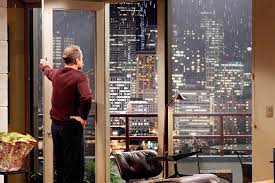

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_pickle("data/housing_cleaned.pkl")

**Phase 2 summary:** All four affected columns are now complete, without deleting any rows or roughly guessing values — every decision is based on a substantive justification (dominant value, relationship between columns) or a verified correction.

---

## Hypothesis 2 – "Renovation / Condition / Grade correspond to higher price points"

This hypothesis was assigned to me (Sonson) by the team for investigation. It aligns with our "Condition Discount" assumption: homes in average condition (`condition == 3`) are expected to offer a cheaper entry price with renovation potential. We test this in two steps:

1. First on the **entire dataset**: how do `grade`, `condition`, and renovation status generally relate to price?
2. Then **specifically within Bonnie Brown's middle-class neighborhood** (see section 3.4), based on `price / sqft_living` — because as a seller, what matters to her is the price she can realize for her own home, not an absolute price comparison.

### 3.1 Price by `grade` (entire dataset)

`grade` is King County's own rating system for construction quality/features (3 = low, 13 = very high). We look at the price distribution per grade level.

       count     median          mean
grade                                
3          1   262000.0  2.620000e+05
4         27   200000.0  2.120019e+05
5        242   228700.0  2.485240e+05
6       2038   275276.5  3.019166e+05
7       8974   375000.0  4.025946e+05
8       6065   510000.0  5.429868e+05
9       2615   720000.0  7.737382e+05
10      1134   914327.0  1.072347e+06
11       399  1280000.0  1.497792e+06
12        89  1820000.0  2.202528e+06
13        13  2980000.0  3.710769e+06

Correlation grade <-> price: 0.67


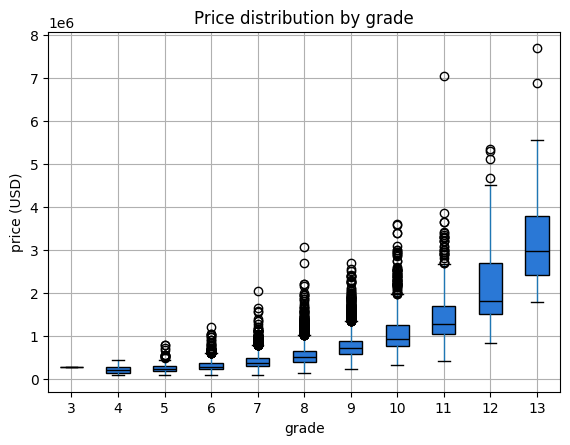

In [3]:
grade_price = df.groupby("grade")["price"].agg(["count", "median", "mean"])
print(grade_price)
print("\nCorrelation grade <-> price:", df["grade"].corr(df["price"]).round(2))

fig, ax = plt.subplots()
df.boxplot(column="price", by="grade", ax=ax, patch_artist=True,
           boxprops={"facecolor": "#2a78d6", "edgecolor": "black"},
           medianprops={"color": "black"})
ax.set_title("Price distribution by grade")
ax.set_xlabel("grade")
ax.set_ylabel("price (USD)")
plt.suptitle("")
plt.show()

**Observation:** A very clear, almost monotonic relationship — the median price rises from $262,000 (grade 3) to $2,980,000 (grade 13). Correlation `grade` ↔ `price`: **0.67** — the strongest single factor we've seen so far. For Hypothesis 2, this means: **grade clearly confirms the hypothesis.**

### 3.2 Price by `condition` (entire dataset)

`condition` rates the general upkeep/condition of the home (1 = poor, 5 = very good).

           count    median           mean
condition                                
1             29  270000.0  341067.241379
2            170  279000.0  328178.758824
3          14020  450250.0  542173.057347
4           5677  440000.0  521374.450414
5           1701  526000.0  612577.742504

Correlation condition <-> price: 0.04


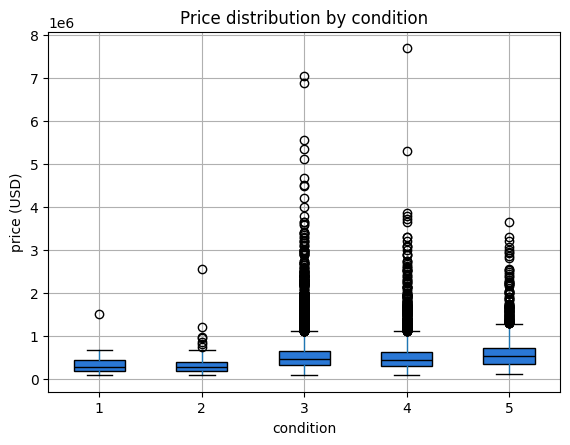

In [4]:
condition_price = df.groupby("condition")["price"].agg(["count", "median", "mean"])
print(condition_price)
print("\nCorrelation condition <-> price:", df["condition"].corr(df["price"]).round(2))

fig, ax = plt.subplots()
df.boxplot(column="price", by="condition", ax=ax, patch_artist=True,
           boxprops={"facecolor": "#2a78d6", "edgecolor": "black"},
           medianprops={"color": "black"})
ax.set_title("Price distribution by condition")
ax.set_xlabel("condition")
ax.set_ylabel("price (USD)")
plt.suptitle("")
plt.show()

**Observation:** Unlike `grade`, the relationship here is **weak** — correlation `condition` ↔ `price`: only **0.04**. `condition == 3` (median $450,250) is barely different from `condition == 4` ($440,000), and even slightly *below* `condition == 5` ($526,000), though above `condition == 1`/`2` (small samples, 29 and 170 homes respectively). For Hypothesis 2, this means: **`condition` alone barely explains price across the whole market** — the effect implied by the hypothesis seems to run almost entirely through `grade`, not through `condition`.

### 3.3 Renovated vs. non-renovated homes (entire dataset)

We derive a simple flag `is_renovated` from `yr_renovated` (`yr_renovated > 0`) and compare both the absolute price and price per square foot (`price / sqft_living`), to control for size effects.

              count    median           mean
is_renovated                                
False         20853  449000.0  532140.319858
True            744  607502.0  768901.892473

                  median        mean
is_renovated                        
False         243.190661  262.102755
True          301.562882  321.338135

Correlation is_renovated <-> price: 0.12


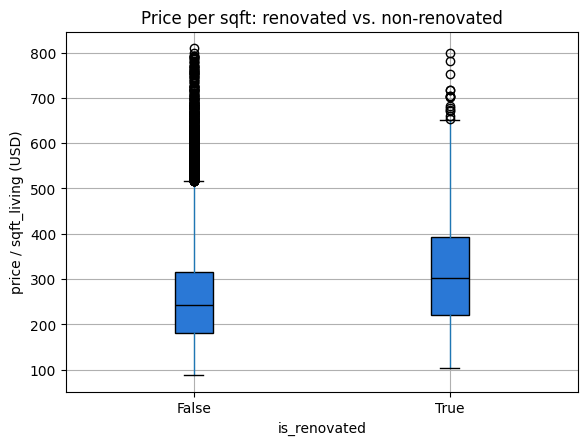

In [5]:
df["is_renovated"] = df["yr_renovated"] > 0
df["price_per_sqft"] = df["price"] / df["sqft_living"]

print(df.groupby("is_renovated")["price"].agg(["count", "median", "mean"]))
print()
print(df.groupby("is_renovated")["price_per_sqft"].agg(["median", "mean"]))
print("\nCorrelation is_renovated <-> price:", df["is_renovated"].astype(int).corr(df["price"]).round(2))

fig, ax = plt.subplots()
df.boxplot(column="price_per_sqft", by="is_renovated", ax=ax, patch_artist=True,
           boxprops={"facecolor": "#2a78d6", "edgecolor": "black"},
           medianprops={"color": "black"})
ax.set_title("Price per sqft: renovated vs. non-renovated")
ax.set_xlabel("is_renovated")
ax.set_ylabel("price / sqft_living (USD)")
plt.suptitle("")
plt.show()

**Observation:** Renovated homes (744 of 21,597, ~3.4%) sell for a median of **$607,502** vs. **$449,000** for non-renovated ones — the median price per square foot is also higher: **$302** vs. **$243**. Correlation `is_renovated` ↔ `price`: **0.12** — moderate, weaker than `grade` but clearly stronger than `condition`. Renovation does show a visible price premium.

### 3.4 Bonnie's real role: seller in a middle-class neighborhood

**Correction (persona):** The analysis from this point on originally assumed, incorrectly, that Bonnie is a buyer with a budget ≤ $500,000. Per the official assignment (`01_assignment.md`), Bonnie Brown is actually a **seller**: she already owns a home in a **middle-class neighborhood**, wants to move soon, and wants to maximize her profit on the sale.

**Update (pipeline):** The team has since agreed on a shared, team-wide definition of "middle-class neighborhood" (`02_middle_class_neighbourhoods.ipynb`, result in `data/middle_class_zip_pps.pkl`): zipcodes are split into terciles by **average price per square foot** (rather than median price, as in our original version). We now adopt this shared definition to stay consistent with Hypothesis 1 (Evelyn, already migrated), instead of continuing our own calculation.

In [6]:
bonnie = pd.read_pickle("data/middle_class_zip_pps.pkl")
bonnie["is_renovated"] = bonnie["yr_renovated"] > 0

print(f"Homes in middle-class neighborhoods (team pipeline): {len(bonnie)} ({len(bonnie) / len(df):.1%} of the overall market)")
print(f"Zipcodes: {bonnie['zipcode'].nunique()} of {df['zipcode'].nunique()}")

Homes in middle-class neighborhoods (team pipeline): 7604 (35.2% of the overall market)
Zipcodes: 24 of 70


**Observation:** Under the team-wide pipeline, the middle-class neighborhood segment covers **7,604 homes** (35.2% of the market) across **24 zipcodes** — somewhat more than our original version (6,791 homes, 22 zipcodes). Importantly, these are **not the same** zipcodes — only 10 of the ~22–24 zipcodes overlap between the two definitions (median price vs. price/sqft). As shown below, this has a noticeable effect on our results.

#### `condition == 3` vs. other conditions — within middle-class neighborhoods

In [7]:
bonnie.groupby(bonnie["condition"] == 3)["price_per_sqft"].agg(["count", "median", "mean"])

,count,median,mean
condition,,,
False,2202,251.835017,263.180194
True,5402,246.153846,251.386657


**Observation:** Within the (newly defined) middle-class neighborhoods, the median price per square foot for `condition == 3` (5,402 homes) is **$246**, compared to **$252** for better-rated conditions (2,202 homes) — a discount of only about **2%**. Compared to our old segment definition (~10%), the discount points in the same direction but is much weaker under the team-wide definition.

#### ROI analysis: is renovating before selling worth it?

Bonnie's actual question: her home has `condition == 3`. Would renovating before selling increase her profit enough to be worth it? We compare already-renovated vs. non-renovated homes *within* `condition == 3`, in middle-class neighborhoods.

             price                          price_per_sqft              \
             count    median           mean          count      median   
is_renovated                                                             
False         5246  485000.0  541387.979032           5246  246.206365   
True           156  458000.0  547359.198718            156  238.343195   

                          
                    mean  
is_renovated              
False         251.303215  
True          254.192642  

Median price renovated: 458,000 $ vs. non-renovated: 485,000 $ -> -5.6 %
Median price/sqft renovated: 238 $ vs. non-renovated: 246 $ -> -3.2 %
Correlation is_renovated <-> price: 0.0


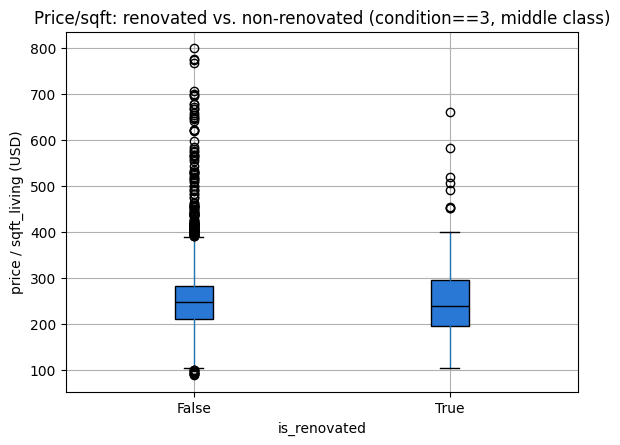

In [8]:
bonnie_cond3 = bonnie[bonnie["condition"] == 3].copy()

print(bonnie_cond3.groupby("is_renovated")[["price", "price_per_sqft"]].agg(["count", "median", "mean"]))

median_price_reno = bonnie_cond3.loc[bonnie_cond3["is_renovated"], "price"].median()
median_price_noreno = bonnie_cond3.loc[~bonnie_cond3["is_renovated"], "price"].median()
price_uplift_pct = (median_price_reno / median_price_noreno - 1) * 100

median_psf_reno = bonnie_cond3.loc[bonnie_cond3["is_renovated"], "price_per_sqft"].median()
median_psf_noreno = bonnie_cond3.loc[~bonnie_cond3["is_renovated"], "price_per_sqft"].median()
psf_uplift_pct = (median_psf_reno / median_psf_noreno - 1) * 100

print(f"\nMedian price renovated: {median_price_reno:,.0f} $ vs. non-renovated: {median_price_noreno:,.0f} $ -> {price_uplift_pct:+.1f} %")
print(f"Median price/sqft renovated: {median_psf_reno:,.0f} $ vs. non-renovated: {median_psf_noreno:,.0f} $ -> {psf_uplift_pct:+.1f} %")
print("Correlation is_renovated <-> price:", bonnie_cond3["is_renovated"].astype(int).corr(bonnie_cond3["price"]).round(2))

fig, ax = plt.subplots()
bonnie_cond3.boxplot(column="price_per_sqft", by="is_renovated", ax=ax, patch_artist=True,
                     boxprops={"facecolor": "#2a78d6", "edgecolor": "black"},
                     medianprops={"color": "black"})
ax.set_title("Price/sqft: renovated vs. non-renovated (condition==3, middle class)")
ax.set_xlabel("is_renovated")
ax.set_ylabel("price / sqft_living (USD)")
plt.suptitle("")
plt.show()

**Observation:** Within `condition == 3` in middle-class neighborhoods, already-renovated homes (156 of 5,402, ~2.9%) sell for a median of **$458,000** vs. **$485,000** for non-renovated ones — that's **−5.6%** on absolute price and **−3.2%** on price per square foot ($238 vs. $246). Correlation `is_renovated` ↔ `price`: **0.00** — essentially no relationship left.

> ⚠️ **IMPORTANT CORRECTION (2026-08-02): this result directly contradicts our earlier analysis and the recommendation we had already presented.**
>
> Under our original (median-price-based) segment definition, we found a **positive** renovation effect (+36.7% price, +21.7% price/sqft, correlation 0.14) and recommended that Bonnie renovate before selling. Under the now team-agreed (price/sqft-based) segment definition, **the result reverses**: no longer a positive effect, but a slightly negative one, with essentially no correlation.
>
> **Why the difference?** Not a data or calculation error — both were checked (whole-market correlations match exactly, and `price_per_sqft` in the shared pickle was cross-checked row by row). The two methods simply select **different zipcodes** as "middle class" (only 10 of ~22–24 overlap). The renovation effect we found earlier was apparently specific to the zipcodes in our original definition, not robust across both definitions.
>
> **Consequence:** The recommendation "renovating before selling pays off" **is no longer supported by the current, team-agreed data**. We correct our conclusion accordingly (see summary below).

#### `grade` within middle-class neighborhoods (context)

For context: does the strong relationship between `grade` and price (3.1, correlation 0.67) also hold within middle-class neighborhoods, or was it — as in the old, budget-capped analysis — just an artifact?

       count      median        mean
grade                               
4         13  322.077922  377.976969
5         66  250.000000  299.942829
6        781  260.245902  272.372462
7       2932  240.601504  247.746446
8       2106  247.792398  250.813036
9       1020  247.838663  253.976819
10       499  251.002825  265.552689
11       158  265.024481  279.442957
12        29  308.115543  336.438592

Correlation grade <-> price (middle-class segment): 0.75


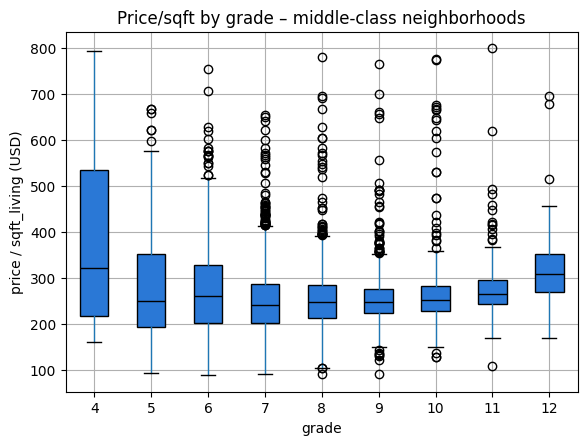

In [9]:
bonnie_grade = bonnie.groupby("grade")["price_per_sqft"].agg(["count", "median", "mean"])
print(bonnie_grade)
print("\nCorrelation grade <-> price (middle-class segment):", bonnie["grade"].corr(bonnie["price"]).round(2))

fig, ax = plt.subplots()
bonnie.boxplot(column="price_per_sqft", by="grade", ax=ax, patch_artist=True,
               boxprops={"facecolor": "#2a78d6", "edgecolor": "black"},
               medianprops={"color": "black"})
ax.set_title("Price/sqft by grade – middle-class neighborhoods")
ax.set_xlabel("grade")
ax.set_ylabel("price / sqft_living (USD)")
plt.suptitle("")
plt.show()

**Observation:** The correlation between `grade` and price remains strong under the new segment definition too — even slightly stronger than the overall market: **0.75** (vs. 0.67 overall; previously 0.65 with our old segment definition). So `grade` is a robust price driver across both middle-class definitions — unlike the renovation/condition findings, which change substantially depending on the segment definition.

## Summary: Hypothesis 2 – Renovation ROI

> ⚠️ **Updated (2026-08-02):** This summary was corrected after switching to the team-wide middle-class pipeline (`data/middle_class_zip_pps.pkl`). The previous version of this notebook (see git history) recommended renovating — that conclusion **no longer holds** under the current, team-agreed data basis.

| Factor | Overall market | Middle-class neighborhoods (team pipeline, Bonnie's segment) |
|---|---|---|
| `grade` | Strong driver (correlation 0.67) | Still a strong driver (correlation 0.75) |
| `condition` | Weak (correlation 0.04) | `condition == 3`: only **~2% discount** vs. better-rated homes ($246 vs. $252/sqft) — previously (old segment definition): ~10% |
| Renovation (condition==3) | Moderate (correlation 0.12), +35% median price | **−5.6%** median price, **−3.2%** price/sqft for renovated homes (correlation 0.00) — previously (old segment definition): **+36.7% / +21.7%** |

**Conclusion for Bonnie Brown (seller):** `grade` remains a robust contextual price driver. The `condition == 3` discount is real but smaller than originally reported (~2% instead of ~10%) under the team-wide segment definition. **The renovation effect we previously found does not hold up under the team-wide middle-class definition** — the relationship is essentially null to slightly negative with this data. **We are retracting our earlier recommendation** ("renovating pays off"). Based on the current data, we cannot confidently promise Bonnie a price return on renovating before selling.

**Why the result changed so much:** our old and the current middle-class definitions select different zipcodes (only 10 of ~22–24 overlap) — the renovation effect we found was apparently specific to the zipcodes in our original definition, not robust across both definitions.

**Next steps:** Hypothesis 1 (location value, already migrated by Evelyn) and Hypothesis 3 (timing) follow the same pipeline. The team should factor this correction in before the final submission/presentation, in case the earlier recommendation was already communicated.